# Clustering Data Using Scikit-Learn

使用 scikit-learn 進行客戶流失風險分群分析，比較 4 種分群演算法（K-Means、Mean Shift、DBSCAN、階層式分群）的效果。

## 1. 安裝套件

In [1]:
# 使用 uv 套件管理器安裝本專案所需的所有 Python 套件
# pandas: 資料處理與分析框架
# numpy: 數值計算函式庫
# matplotlib: 基礎繪圖函式庫
# seaborn: 基於 matplotlib 的統計視覺化函式庫
# plotly: 互動式圖表函式庫（支援 3D 旋轉、縮放、提示框）
# scikit-learn: 機器學習演算法函式庫（包含分群演算法）
# scikit-plot: 用於快速繪製機器學習評估圖表
# !uv pip install pandas numpy matplotlib seaborn plotly scikit-learn scikit-plot

## 2. 匯入函式庫

In [2]:
# 讓 matplotlib 圖表直接嵌入 notebook 中顯示（不另開視窗）
%matplotlib inline
# 匯入 sleep 函式，用於動畫播放時的暫停間隔
from time import sleep
# 匯入 Jupyter 的顯示與清除輸出功能，用於製作動畫效果
from IPython.display import display, clear_output
# 匯入 matplotlib 主模組
import matplotlib as mpl
# 匯入 matplotlib 的動畫模組
import matplotlib.animation
# 匯入 matplotlib 的色彩映射（colormap）模組，提供預定義的色彩方案
import matplotlib.cm as cm
# 匯入 matplotlib 的繪圖介面
import matplotlib.pyplot as plt
# 匯入 matplotlib 的樣式模組
import matplotlib.style as style
# 匯入 matplotlib 的線條物件
from matplotlib import lines
# 匯入自訂色彩映射類別，用於手動指定分群的顏色
from matplotlib.colors import ListedColormap
# 匯入 3D 繪圖軸支援
from mpl_toolkits.mplot3d import Axes3D
# 匯入 NumPy 數值計算函式庫
import numpy as np
# 匯入 Pandas 資料處理函式庫
import pandas as pd
# 匯入 Plotly Express，用於快速建立互動式圖表
import plotly.express as px
# 匯入 Seaborn 統計視覺化函式庫
import seaborn as sns
# 匯入 Mean Shift 的頻寬估計函式
from sklearn.cluster import estimate_bandwidth
# 匯入 K-Means 分群演算法
from sklearn.cluster import KMeans
# 匯入 Mean Shift 分群演算法
from sklearn.cluster import MeanShift
# 匯入合成資料產生器：make_blobs 產生球形分群、make_moons 產生月亮形分群
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons

## 3. 載入客戶資料

In [3]:
# 從 IBM GitHub 儲存庫載入客戶交易資料 CSV 檔案
# 此資料集包含客戶基本資訊、交易行為及流失風險標籤（CHURNRISK）
df = pd.read_csv("https://raw.githubusercontent.com/IBM/ml-learning-path-assets/master/data/mergedcustomers.csv")

## 4. 準備客戶資料

移除 CHURNRISK 欄位（留作外部評估用），計算 PROFIT_YTD，選取數值特徵。

In [4]:
# 將 CHURNRISK（流失風險）欄位單獨儲存，稍後用於「外部評估」
# 外部評估：用已知標籤來驗證分群結果是否有意義
known_risk = df['CHURNRISK']

# 定義要保留的特徵欄位名稱（用於分群的數值特徵）
# AGE: 客戶年齡
# TOTALUNITSTRADED: 總交易單位數
# DAYSSINCELASTTRADE: 距離上次交易天數
# DAYSSINCELASTLOGIN: 距離上次登入天數
# PROFIT_YTD: 年度至今淨利（下方計算）
keep_columns = ['AGE', 'TOTALUNITSTRADED', 'DAYSSINCELASTTRADE', 'DAYSSINCELASTLOGIN', 'PROFIT_YTD']

# 計算 PROFIT_YTD = 已實現獲利 - 已實現虧損，並只保留指定的特徵欄位
# assign() 新增 PROFIT_YTD 欄位，apply() 逐列計算淨利
df_churn = df.assign(PROFIT_YTD=df.apply(lambda row: row.NETREALIZEDGAINS_YTD - row.NETREALIZEDLOSSES_YTD, axis=1).values)[keep_columns]

# 選定 3 個特徵作為 3D 圖表的 X、Y、Z 軸
x_name = 'AGE'           # X 軸：客戶年齡
y_name = 'PROFIT_YTD'    # Y 軸：年度淨利
z_name = 'DAYSSINCELASTTRADE'  # Z 軸：距離上次交易天數

# 顯示前 5 筆資料，確認資料結構正確
df_churn.head()

,AGE,TOTALUNITSTRADED,DAYSSINCELASTTRADE,DAYSSINCELASTLOGIN,PROFIT_YTD
0,47,58,13,2,-152.76525
1,25,13,10,4,1349.63500
2,42,28,5,4,1123.61250
3,52,36,6,3,-652.56550
4,40,8,9,4,-1496.14950


## 5. 產生合成資料集

scikit-learn 的 `make_blobs()` 產生超球體分群資料，`make_moons()` 產生月亮形資料，用於展示不同演算法的特性差異。

In [5]:
# --- 產生合成超球體資料（Blobs）---
# 設定產生 10 個特徵維度（雖然 3D 圖只顯示 3 個，但分群運算使用全部 10 維）
n_features = 10
# 設定樣本數量為 1000 筆
n_samples = 1000
# 設定隨機種子，確保每次產生的資料相同（可重現性）
random_state = 100

# make_blobs() 產生球形分群的合成資料
# 回傳值：blobs = 特徵矩陣 (1000, 10)，blob_labels = 每筆資料所屬的分群標籤
blobs, blob_labels = make_blobs(n_samples=n_samples, n_features=n_features, random_state=random_state)

# 將 NumPy 陣列轉為 DataFrame，並命名前 3 維為 X、Y、Z（用於 3D 繪圖）
blobs_df = pd.DataFrame(blobs, columns=['X', 'Y', 'Z', 'A', 'B', 'C', 'D', 'E', 'F', 'G'])
# 加入分群標籤欄位，用於視覺化著色
blobs_df['CLUSTER'] = blob_labels

# --- 產生合成月亮形資料（Moons）---
# make_moons() 產生 2 維的月亮形資料，用於展示不同演算法對非球形分佈的處理能力
# noise=0.05 加入少量雜訊使資料更真實
moons, moon_labels = make_moons(n_samples=n_samples, noise=.05)

## 6. 視覺化設定與輔助函式

定義 4 個共用函式：3D 散佈圖、2D 月亮圖、Plotly 互動圖、分群 vs 風險堆疊長條圖。

In [6]:
# 設定 seaborn 圖表風格為深色格線背景
sns.set(style='darkgrid')
# 設定 matplotlib 預設圖表尺寸（寬 8 吋、高 3 吋）
plt.rcParams['figure.figsize'] = [8, 3]

# ===== 輔助函式 1：3D 散佈圖 =====
# 繪製 matplotlib 3D 散佈圖，支援分群著色、中心點標記、視角旋轉等功能
# 參數說明：
#   df: 資料 DataFrame
#   x_name, y_name, z_name: 用作 X/Y/Z 軸的欄位名稱
#   predicted: 分群預測結果（用於著色）
#   centers: 分群中心點座標（若提供則以紅色 X 標記）
#   cmap: 色彩映射；alpha: 透明度；elev/azim: 3D 視角的仰角與方位角
#   xlim3d/ylim3d/zlim3d: 可選的軸範圍限制
def show_scatter_3d(df, x_name, y_name, z_name, predicted=None, centers=None,
                    marker='o', cmap=None, edgecolors=None, alpha=0.3,
                    elev=25, azim=10, show_colorbar=True,
                    xlim3d=None, ylim3d=None, zlim3d=None):
    # 建立新的圖表物件
    fig = plt.figure()
    # 新增 3D 子圖（111 表示 1 列 1 欄的第 1 個子圖）
    ax = fig.add_subplot(111, projection='3d')

    # 取得指定欄位在 DataFrame 中的索引位置（用於從中心點陣列取值）
    x_index = df.columns.get_loc(x_name)
    y_index = df.columns.get_loc(y_name)
    z_index = df.columns.get_loc(z_name)

    # 取出 X、Y、Z 軸的資料
    x = df[x_name]
    y = df[y_name]
    z = df[z_name]

    # 若有提供分群中心點，則以紅色大型 X 標記繪製在圖上
    if centers is not None:
        spot_size=15  # 資料點縮小，讓中心點的 X 標記更明顯
        for center in centers:
            if center is not None:
                # 在中心點位置繪製紅色 X 標記（s=500 為較大的標記尺寸）
                ax.scatter(center[x_index], center[y_index], center[z_index], marker="X", s=500, color='red')
    else:
        spot_size=30  # 沒有中心點時，資料點稍微放大

    # 判斷 predicted 是否為字串顏色（如 'r', 'g', 'b'），若是則不使用 cmap
    try:
        is_string_colors = any(isinstance(v, str) for v in (predicted[:5] if hasattr(predicted, '__len__') else []))
    except Exception:
        is_string_colors = False

    # 若未指定色彩映射且非字串顏色，則根據分群數量自動產生 seaborn Set2 調色盤
    if not cmap and not is_string_colors:
        cmap = ListedColormap(sns.color_palette("Set2",len(set(predicted))))

    # 繪製 3D 散佈圖，c=predicted 用分群標籤著色
    if is_string_colors:
        # 字串顏色直接傳給 c 參數，不需 cmap
        chart = ax.scatter(x, y, z, c=predicted, marker=marker, edgecolors=edgecolors, s=spot_size, alpha=alpha)
    else:
        chart = ax.scatter(x, y, z, c=predicted, marker=marker, edgecolors=edgecolors, cmap=cmap, s=spot_size, alpha=alpha)

    # 設定三個軸的標籤文字
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_zlabel(z_name)

    # 若有指定軸範圍限制，則套用（用於動畫中固定視角範圍）
    if xlim3d:
        ax.set_xlim3d(xlim3d)
    if ylim3d:
        ax.set_ylim3d(ylim3d)
    if zlim3d:
        ax.set_zlim3d(zlim3d)

    # 調整圖表邊界，為軸標籤留出空間
    plt.subplots_adjust(bottom=1, top=3, left=0, right=2)

    # 設定 3D 圖表的觀看角度（仰角 elev、方位角 azim）
    ax.view_init(elev, azim)

    # 若 show_colorbar=True，則顯示色彩對照條（標示各分群對應的顏色）
    if show_colorbar:
        fig.colorbar(chart, ticks=list(set(predicted)))

    # 回傳圖表與軸物件，供後續動畫使用
    return fig, ax

# ===== 輔助函式 2：2D 月亮形散佈圖 =====
# 取得 RdYlBu（紅-黃-藍）色彩映射，適合二分類的月亮形資料
RdYlBu = plt.get_cmap('RdYlBu')

# 繪製 2D 散佈圖，專門用於月亮形資料的視覺化
# data: 2D 座標陣列；prediction: 分群標籤；centers: 中心點（可選）
def show_scatter_moons(data, prediction, centers=[]):
    # 以分群標籤著色繪製散佈圖
    plt.scatter(data[:, 0], data[:, 1], c=prediction, cmap=RdYlBu, alpha=0.5);
    # 若有中心點，以紅色大型 X 標記顯示
    for center in centers:
        plt.scatter(center[0], center[1], marker="X", s=300, color='red')

# ===== 輔助函式 3：Plotly 互動式 3D 散佈圖 =====
# 使用 Plotly Express 建立可旋轉、縮放、顯示提示框的互動式 3D 圖表
def plotly_scatter_3d(df, x, y, z, color=None):
    fig = px.scatter_3d(df, x=x, y=y, z=z, color=color,
                    opacity=0.2,                          # 設定透明度為 0.2
                    template='plotly_dark',                # 使用深色主題
                    color_continuous_scale=px.colors.qualitative.Set1)  # 使用 Set1 調色盤
    fig.show()  # 顯示互動圖表

# ===== 輔助函式 4：外部評估堆疊長條圖 =====
# 用堆疊長條圖比對「分群結果」與「已知流失風險標籤」
# 這是一種「外部評估」方法：用事先已知的真實標籤來驗證分群品質

# 將風險等級映射為可排序的字串（用於圖表圖例排序）
risk_map = {'High': '2: High', 'Medium': '1: Medium', 'Low': '0: Low'}

# 繪製分群 vs 風險的堆疊長條圖
# data: 分群預測結果；risk: 已知的 CHURNRISK 標籤
def show_risk_by_cluster(data, risk):

    # 建立 DataFrame，包含每筆資料的分群 ID
    data_df = pd.DataFrame(data=data, columns=['CLUSTER'])

    # 加入已知風險標籤（使用可排序的映射值）
    data_df['CHURN_RISK'] = risk.map(risk_map)

    # 依分群 ID 與風險等級分組計數（每個分群中有多少 High/Medium/Low）
    grouped_data = data_df.groupby(['CLUSTER', 'CHURN_RISK']).size().to_frame().reset_index()

    # 樞紐轉換：列=分群ID，欄=風險等級，值=計數，缺失填 0
    pivot = grouped_data.pivot(index='CLUSTER', columns='CHURN_RISK', values=0).fillna(0)

    # 排序：High 最多的分群排在前面，相同時 Low 最少的排前面
    pivot = pivot.reindex(pivot.sort_values(by=['2: High', '0: Low'], ascending=[False, True]).index)

    # 繪製堆疊長條圖，顏色 g=綠(Low)、b=藍(Medium)、r=紅(High)
    pivot.plot(kind='bar', stacked=True, color='gbr')

    # 將圖例放在圖表右側外部，避免遮擋資料
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

## 7. 視覺化 — Blobs 資料

使用 matplotlib 3D 散佈圖與 Plotly 互動圖檢視合成超球體資料的分佈。

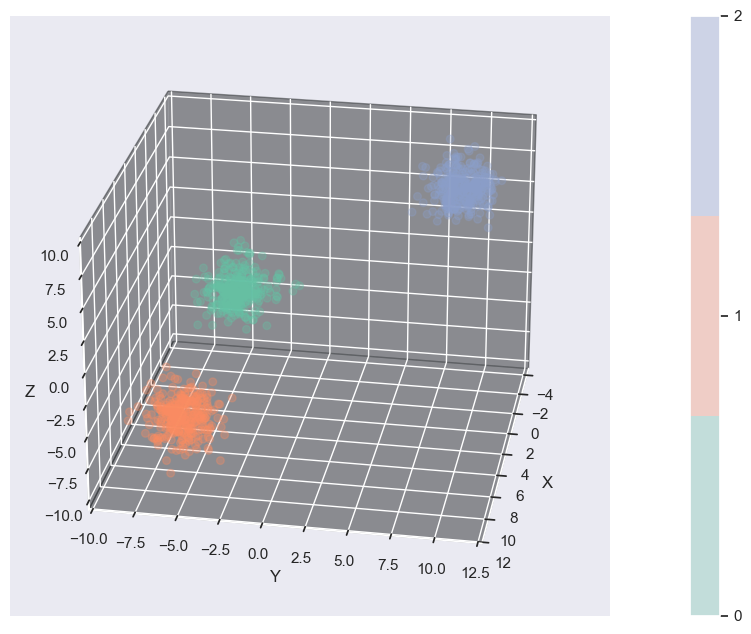

In [7]:
# 使用 matplotlib 繪製 Blobs 合成資料的 3D 散佈圖
# predicted=blob_labels 用真實的分群標籤著色，確認資料分佈
show_scatter_3d(blobs_df, 'X', 'Y', 'Z', predicted=blob_labels);

# 使用 Plotly 繪製相同資料的互動式 3D 圖表
# 互動圖表可旋轉、縮放、滑鼠懸停顯示提示框
# 當分群在 3D 空間中重疊時，旋轉視角特別有幫助
plotly_scatter_3d(blobs_df, 'X', 'Y', 'Z', color='CLUSTER')

## 8. 視覺化 — Moons 資料

月亮形資料集僅有 2 維，用於展示不同分群演算法對非球形分佈的處理能力差異。

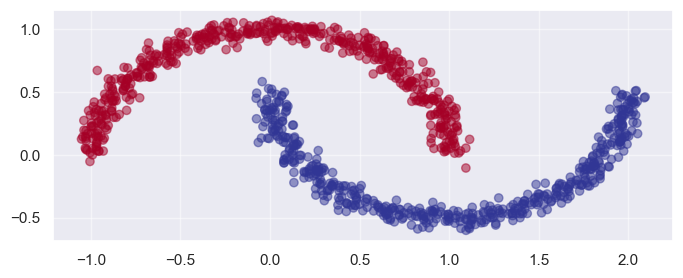

In [8]:
# 月亮形資料集只有 2 維，但能清楚展示不同分群演算法的差異
# K-Means 無法正確處理這種非凸形狀，而 DBSCAN 可以
show_scatter_moons(moons, moon_labels)

## 9. 視覺化 — 客戶資料

以已知的 CHURNRISK 標籤（High/Medium/Low）著色，觀察客戶資料在 3D 空間中的分佈。

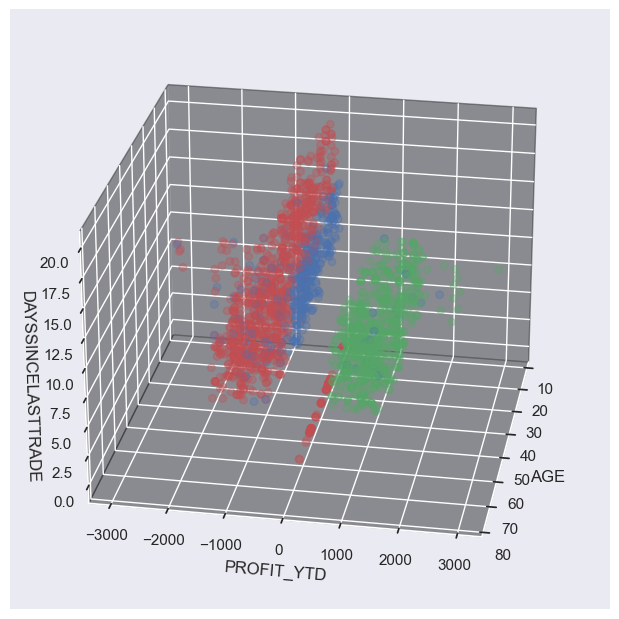

In [9]:
# 尚未進行分群，先用已知的流失風險標籤（CHURNRISK）著色
# High=紅色、Medium=藍色、Low=綠色
label_colors = known_risk.map({'High': 'r', 'Medium': 'b', 'Low': 'g'})

# 繪製客戶資料的 3D 散佈圖，觀察資料在特徵空間中的分佈
# show_colorbar=False 因為此處著色是類別標籤而非數值
show_scatter_3d(df_churn, x_name, y_name, z_name, predicted=label_colors, show_colorbar=False);

## 10. K-Means — Blobs

K-Means 對超球體形狀的分群效果最佳，因為其假設分群為球形。

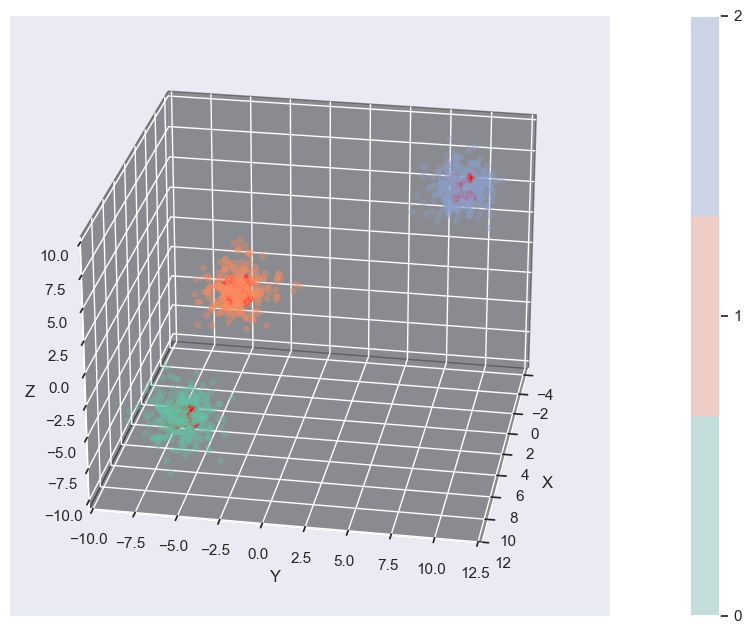

In [10]:
# 設定分群數 k=3（與 Blobs 資料的真實分群數相同）
k = 3
# 建立 K-Means 分群器，指定分群數量
kmeans = KMeans(n_clusters=k)
# fit_predict() = fit() + predict()：先學習資料結構，再回傳每筆資料的分群標籤
y_pred = kmeans.fit_predict(blobs)
# 取得每個分群的中心點座標（10 維空間中的中心）
centers = kmeans.cluster_centers_

# 繪製分群結果的 3D 散佈圖，紅色 X 標記為分群中心
# K-Means 對球形分群效果最佳，因此結果應與真實標籤高度吻合
show_scatter_3d(blobs_df, 'X', 'Y', 'Z', predicted=y_pred, centers=centers);

## 11. K-Means — Moons

K-Means 無法正確辨識月亮形分群，因為其基於距離中心點的假設不適用於非凸形狀。

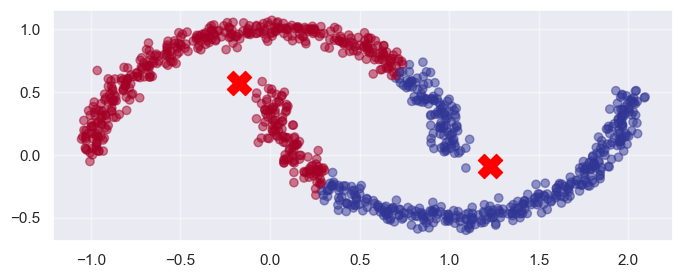

In [11]:
# 設定分群數 k=2（月亮形資料有 2 個月亮）
k = 2
# 建立 K-Means 分群器
kmeans = KMeans(n_clusters=k)
# 對月亮形資料進行分群
y_pred = kmeans.fit_predict(moons)
# 取得 2 個分群中心點
centers = kmeans.cluster_centers_

# 繪製結果 — K-Means 會將月亮形資料錯誤地以直線分割
# 這是因為 K-Means 假設分群為球形（凸形），無法辨識月亮形的弧狀結構
show_scatter_moons(moons, y_pred, centers)

## 12. K-Means — 客戶資料

對客戶資料進行 K-Means 分群（k=3），觀察分群結果是否與流失風險類別吻合。

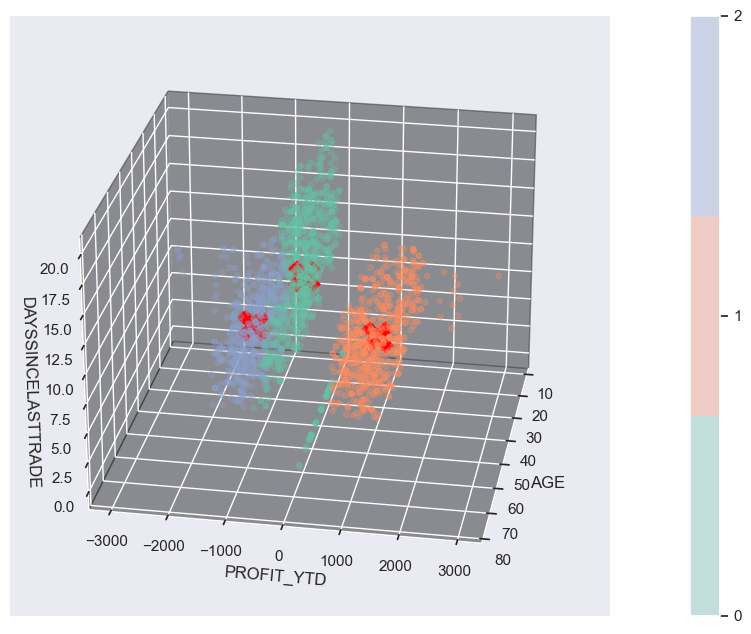

In [12]:
# 設定分群數為 3（對應 High/Medium/Low 三種流失風險）
n_clusters = 3
# 建立 K-Means 分群器
kmeans = KMeans(n_clusters=n_clusters)
# 對客戶資料進行分群，.values 將 DataFrame 轉為 NumPy 陣列
predicted = kmeans.fit_predict(df_churn.values)
# 取得 3 個分群中心點座標
centers = kmeans.cluster_centers_

# 繪製 3D 散佈圖，觀察 K-Means 將客戶分成的 3 個群組
show_scatter_3d(df_churn, x_name, y_name, z_name, predicted=predicted, centers=centers);

## 13. K-Means — 外部評估與 Plotly

透過堆疊長條圖比對 K-Means 分群結果與已知 CHURNRISK 標籤，並用 Plotly 進行互動式 3D 視覺化。

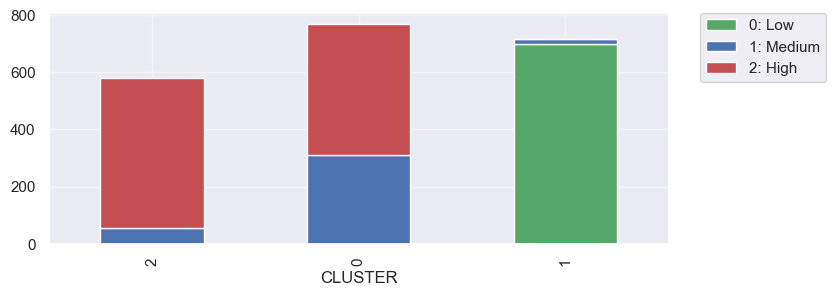

In [13]:
# 外部評估：用堆疊長條圖比對 K-Means 分群結果與已知的 CHURNRISK 標籤
# 若分群結果有意義，每個分群應該會集中在某一個風險等級
show_risk_by_cluster(predicted, known_risk)

# 複製客戶資料並加入分群結果欄位
X_df = df_churn.copy()
X_df['CLUSTER'] = predicted
# 使用 Plotly 互動式 3D 圖表觀察分群分佈
# 可透過旋轉發現 K-Means 的分群主要受 PROFIT_YTD 欄位影響
plotly_scatter_3d(X_df, x_name, y_name, z_name, color='CLUSTER')

## 14. Mean Shift — Moons

Mean Shift 是基於密度的演算法，不需事先指定分群數，但對月亮形資料的處理仍有限。

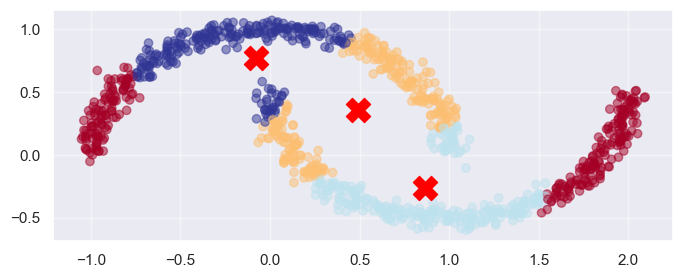

In [14]:
# 使用 estimate_bandwidth() 自動估計最佳頻寬（核密度估計的視窗大小）
# quantile=0.2 表示使用距離分佈的第 20 百分位數作為頻寬
bandwidth = estimate_bandwidth(moons, quantile=.2, n_samples=1000)
# 建立 Mean Shift 分群器
# cluster_all=False：無法歸類的資料點標記為離群點（label=-1）而非強制分群
ms = MeanShift(cluster_all=False, bandwidth=bandwidth)
# 對月亮形資料進行分群
y_pred = ms.fit_predict(moons)
# 取得分群中心點
centers = ms.cluster_centers_

# 繪製分群結果 — Mean Shift 基於密度移動，但對月亮形資料的處理仍有限
show_scatter_moons(moons, y_pred, centers)

## 15. Mean Shift — 客戶資料建模

Mean Shift 的優點：自動偵測分群數量。使用 `cluster_all=False` 可將無法歸類的資料標記為離群點。

In [15]:
# 建立 Mean Shift 分群器（使用預設頻寬）
# cluster_all=False：無法歸類的資料標記為 -1（離群點）
ms = MeanShift(cluster_all=False)
# 對客戶資料進行分群 — Mean Shift 的核心優勢：不需事先指定分群數
predicted = ms.fit_predict(df_churn.values)
# 取得每筆資料的分群標籤
labels = ms.labels_
# 取得演算法自動偵測到的分群中心點
centers = ms.cluster_centers_

# 印出自動偵測到的分群數量
print("Number of clusters: ", len(centers))

Number of clusters:  5


## 16. Mean Shift — 客戶資料 3D 視覺化

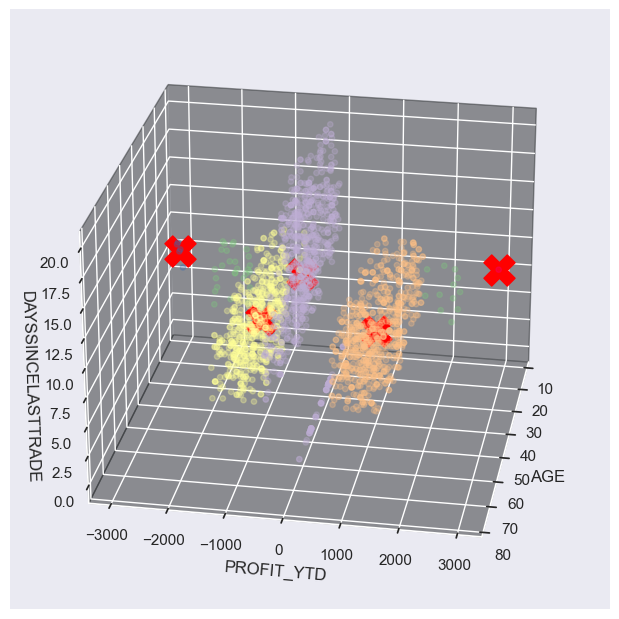

In [16]:
# 繪製 Mean Shift 客戶資料分群結果的 3D 散佈圖
# show_colorbar=False：因為分群數較多，色彩條不易閱讀
# cmap=Accent 色彩映射的前 6 色，用於區分不同分群
show_scatter_3d(df_churn, x_name, y_name, z_name, predicted=predicted, centers=centers,
                show_colorbar=False,
                cmap=ListedColormap(cm.Accent.colors[:6]));

## 17. Mean Shift — 分群與離群點分離動畫

將資料分為分群內與離群點兩組，透過 matplotlib animation 輪播展示分群效果。

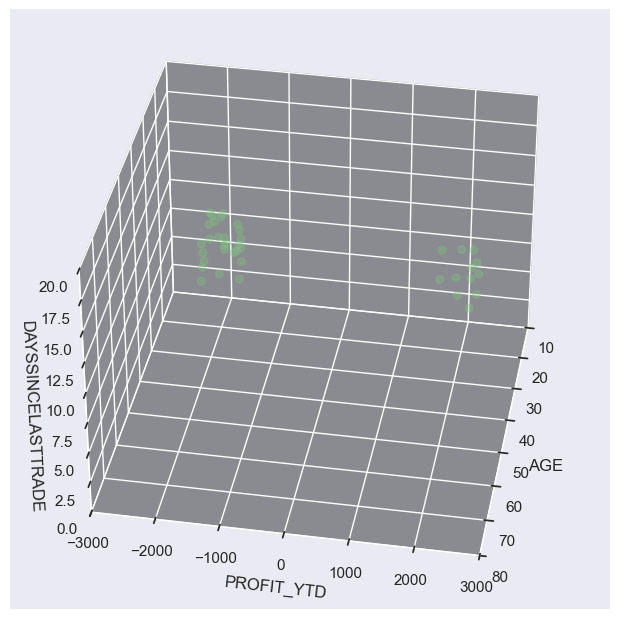

In [17]:
# 複製客戶資料，加入分群標籤欄位
temp_df = df_churn.copy()
temp_df['CLUSTER'] = predicted
# 分離出「有分群歸屬」的資料（CLUSTER != -1）
no_outliers_df = temp_df[temp_df['CLUSTER']!=-1]
# 分離出「離群點」資料（CLUSTER == -1，Mean Shift 無法歸類的資料）
outliers_df = temp_df[temp_df['CLUSTER']==-1]

# 定義動畫的圖表序列 — 輪流顯示不同資料子集，幫助理解分群效果
# 每個字典包含：要顯示的 DataFrame、中心點、色彩映射
charts = [
    {'dataframe': temp_df, 'centers': centers, 'cmap': ListedColormap(cm.Accent.colors[:6])},         # 全部資料 + 中心點
    {'dataframe': outliers_df, 'centers': centers, 'cmap': ListedColormap(cm.Accent.colors[:1])},     # 只顯示離群點
    {'dataframe': temp_df, 'centers': centers, 'cmap': ListedColormap(cm.Accent.colors[:6])},         # 全部資料 + 中心點
    {'dataframe': no_outliers_df, 'centers': centers, 'cmap': ListedColormap(cm.Accent.colors[1:6])}, # 只顯示分群內資料
    {'dataframe': temp_df, 'centers': centers, 'cmap': ListedColormap(cm.Accent.colors[:6])},         # 全部資料 + 中心點
    {'dataframe': no_outliers_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[1:6])},    # 分群內資料（無中心點）
    {'dataframe': temp_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[:6])},            # 全部資料（無中心點）
    {'dataframe': no_outliers_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[1:6])},    # 分群內資料（無中心點）
    {'dataframe': temp_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[:6])},            # 全部資料（無中心點）
    {'dataframe': outliers_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[:1])},        # 只顯示離群點（無中心點）
    {'dataframe': temp_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[:6])},            # 全部資料（無中心點）
    {'dataframe': outliers_df, 'centers': None, 'cmap': ListedColormap(cm.Accent.colors[:1])}         # 只顯示離群點（無中心點）
]

# 動畫播放次數（2 輪，方便觀察）
loops = 2
for loop in range(loops):
  for chart in charts:
    # 清除目前的輸出畫面（wait=True 避免閃爍）
    clear_output(wait=True)
    # 繪製當前幀的 3D 散佈圖，固定視角與軸範圍以產生穩定的動畫效果
    fig, ax = show_scatter_3d(chart['dataframe'], x_name, y_name, z_name, predicted=chart['dataframe']['CLUSTER'],
                centers=chart['centers'],
                show_colorbar=False, cmap=chart['cmap'],
                elev=35, azim=10,                              # 固定 3D 視角
                xlim3d=(10, 80), ylim3d=(-3000, 3000), zlim3d=(0, 20))  # 固定軸範圍

    # 在 notebook 中顯示圖表
    display(fig)
    # 關閉圖表物件以釋放記憶體
    plt.close(fig)
    # 每幀暫停 1 秒
    sleep(1)

## 18. Mean Shift — 外部評估

比對 Mean Shift 分群結果與已知的 CHURNRISK 標籤。

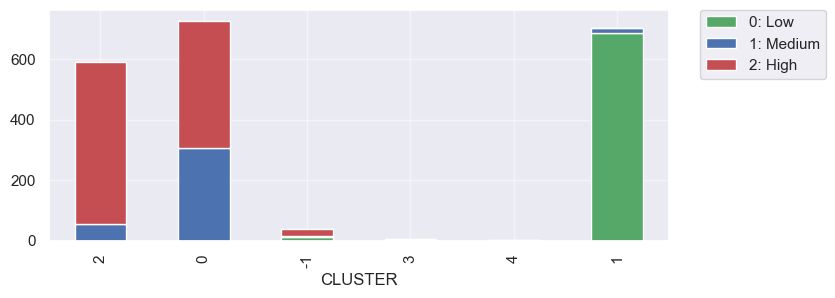

In [18]:
# 外部評估：用堆疊長條圖比對 Mean Shift 分群結果與已知的 CHURNRISK 標籤
# 觀察 Mean Shift 自動偵測的分群是否與客戶流失風險有關聯
show_risk_by_cluster(predicted, known_risk)

## 19. DBSCAN — 客戶資料建模

DBSCAN 基於密度分群，能自動偵測離群點（標記為 -1），不需預先指定分群數。

In [19]:
# 匯入 DBSCAN 分群演算法
# DBSCAN = Density-Based Spatial Clustering of Applications with Noise
# 核心概念：基於密度的分群，能自動偵測離群點（噪音），不需指定分群數
from sklearn.cluster import DBSCAN
# eps=110：鄰域半徑，兩點距離小於 eps 才視為「鄰居」
# eps 越大 → 分群越少（更多點被歸為同一群）；eps 越小 → 分群越多
predicted = DBSCAN(eps=110).fit_predict(df_churn)

# 計算分群數量（排除離群點標籤 -1）
print('Number of clusters:', len(set(predicted)) - (1 if -1 in predicted else 0))
# 計算離群點數量（標籤為 -1 的資料點）
print('Number of outliers:', list(predicted).count(-1))

# 複製客戶資料，加入分群標籤與已知風險標籤
temp_df = df_churn.copy()
temp_df['CLUSTER'] = predicted          # 加入 DBSCAN 預測的分群標籤
temp_df['KNOWN_RISK'] = known_risk      # 加入已知流失風險標籤
# 將所有欄位名稱轉為字串型態（確保後續操作相容性）
temp_df.columns = [str(x) for x in temp_df.columns.values]
# 分離出有分群歸屬的資料（非離群點）
no_outliers_df = temp_df[temp_df['CLUSTER']!=-1]
# 分離出離群點資料
outliers_df = temp_df[temp_df['CLUSTER']==-1]

Number of clusters: 6
Number of outliers: 23


## 20. DBSCAN — 客戶資料視覺化

分別顯示分群內資料與離群點的 3D 散佈圖。

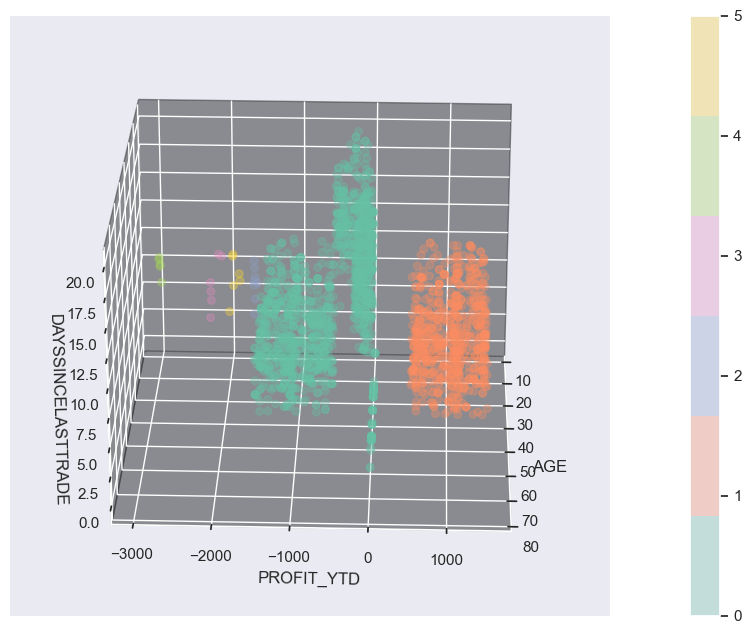

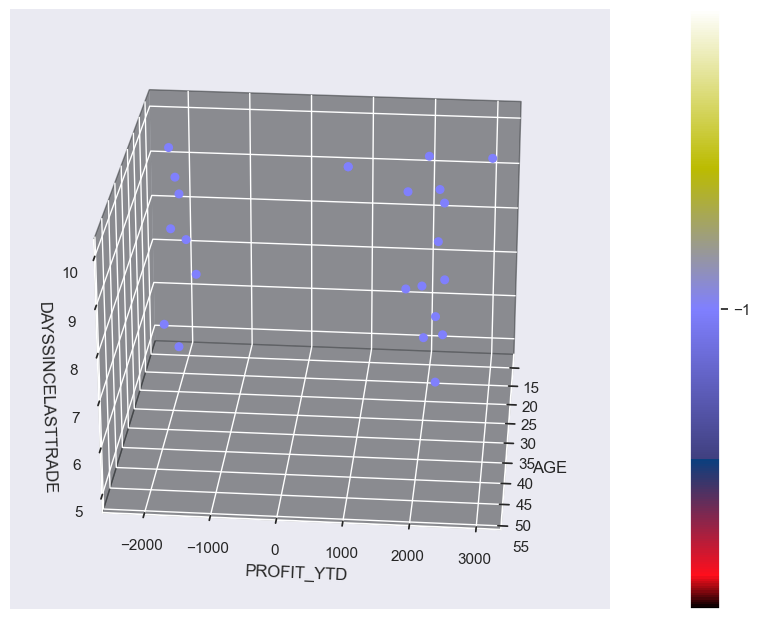

In [20]:
# 繪製「有分群歸屬」的客戶資料 3D 散佈圖
# azim=2 設定水平旋轉角度，方便觀察分群分離效果
show_scatter_3d(no_outliers_df, x_name, y_name, z_name, predicted=no_outliers_df['CLUSTER'], azim=2);

# 繪製「離群點」的 3D 散佈圖
# cmap=gist_stern 使用深色系色彩映射，alpha=1 完全不透明，便於辨識離群點位置
show_scatter_3d(outliers_df, x_name, y_name, z_name, predicted=outliers_df['CLUSTER'], cmap=cm.gist_stern, alpha=1, azim=5);

## 21. DBSCAN — Moons

DBSCAN 能完美辨識月亮形分群，展示密度分群對非凸形狀的優勢。

Number of clusters: 2
Number of outliers: 1


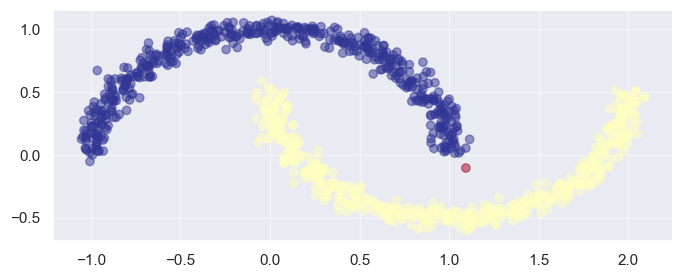

In [21]:
# 使用 DBSCAN 對月亮形資料進行分群
# eps=0.1：使用較小的鄰域半徑（因為月亮形資料的尺度較小）
predicted = DBSCAN(eps=.1).fit_predict(moons)

# 印出分群數與離群點數
print('Number of clusters:', len(set(predicted)) - (1 if -1 in predicted else 0))
print('Number of outliers:', list(predicted).count(-1))

# 繪製結果 — DBSCAN 能完美辨識月亮形的弧狀結構
# 這是 DBSCAN 相對於 K-Means 的最大優勢：不受限於球形假設
show_scatter_moons(moons, predicted)

## 22. 階層式分群 — 建模與外部評估

凝聚式階層分群（Agglomerative Clustering）使用 `distance_threshold` 自動決定分群數。

Number of clusters: 14


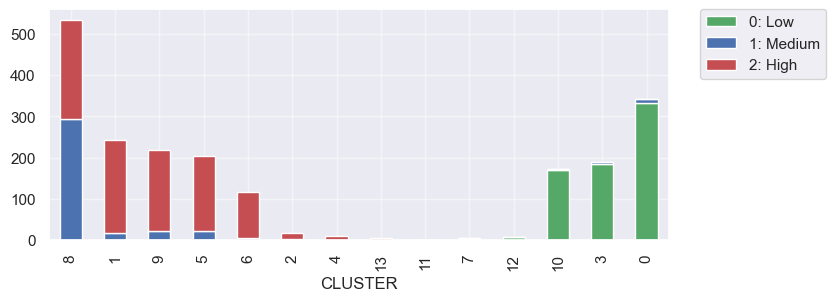

In [22]:
# 匯入凝聚式階層分群演算法
from sklearn.cluster import AgglomerativeClustering
# 建立凝聚式階層分群器
# n_clusters=None：不指定分群數，改用 distance_threshold 自動決定
# distance_threshold=500：當兩個分群的距離超過 500 時停止合併
# metric='euclidean'：使用歐幾里得距離衡量資料點間的距離
# linkage='complete'：完全連結法 — 以兩個分群中最遠的一對資料點距離作為分群間距離
ac = AgglomerativeClustering(n_clusters=None, distance_threshold=500,
                             metric='euclidean', linkage='complete')
# 對客戶資料進行分群
predicted = ac.fit_predict(df_churn.values)

# 印出自動決定的分群數量
print('Number of clusters:', len(set(predicted)))

# 外部評估：比對階層式分群結果與已知的 CHURNRISK 標籤
show_risk_by_cluster(predicted, known_risk)

## 23. 階層式分群 — 視覺化

使用 matplotlib 3D 散佈圖與 Plotly 互動圖檢視階層式分群結果。

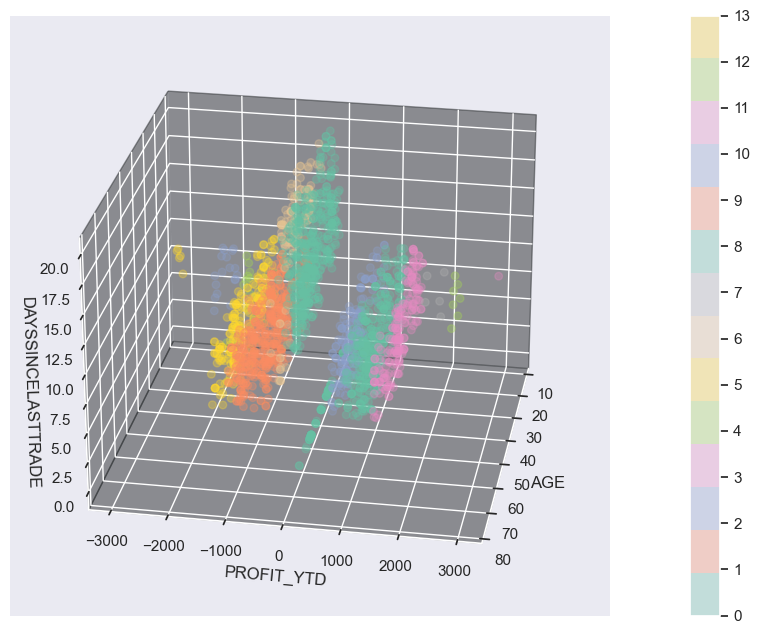

In [23]:
# 使用 matplotlib 繪製階層式分群結果的 3D 散佈圖
show_scatter_3d(df_churn, x_name, y_name, z_name, predicted=predicted);

# 複製資料並加入分群標籤，用 Plotly 建立互動式 3D 圖表
X_df = df_churn.copy()
X_df['CLUSTER'] = predicted
# Plotly 互動圖可旋轉觀察不同角度的分群效果
plotly_scatter_3d(X_df, x_name, y_name, z_name, color='CLUSTER')

<p><font size=-1 color=gray>
&copy; Copyright 2019 IBM Corp. All Rights Reserved.
<p>
Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file
except in compliance with the License. You may obtain a copy of the License at
https://www.apache.org/licenses/LICENSE-2.0
Unless required by applicable law or agreed to in writing, software distributed under the
License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either
express or implied. See the License for the specific language governing permissions and
limitations under the License.
</font></p>